In [1]:
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


## Train on gpu

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda


## Prepare Data

In [3]:
data = pd.read_csv("../data/job_salary_prediction_dataset.csv")
data.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
data["experience_level"] = pd.cut(
    data["experience_years"],
    bins=[0, 2, 5, 10, 50],
    labels=["Junior", "Mid", "Senior", "Expert"],
)

data["skill_density"] = data["skills_count"] / (data["experience_years"] + 1)
data["cert_per_year"] = data["certifications"] / (data["experience_years"] + 1)
data["total_qualifications"] = data["skills_count"] + data["certifications"]

# Interaction features (
data["exp_x_skills"] = data["experience_years"] * data["skills_count"]
data["exp_x_cert"] = data["experience_years"] * data["certifications"]

# Premium features
data["is_tech"] = (data["industry"] == "Tech").astype(int)
data["is_masters_plus"] = (data["education_level"].isin(["Master's", "PhD"])).astype(int)


print(
    data[["experience_level", "skill_density", "total_qualifications", "is_tech"]].head()
)

  experience_level  skill_density  total_qualifications  is_tech
0           Senior       0.181818                     4        0
1              Mid       2.833333                    17        0
2           Expert       0.210526                     5        0
3           Expert       0.650000                    13        0
4           Expert       0.437500                     7        0


In [5]:
X = data.drop(["salary", "experience_level"], axis=1)  # experience_level is derived
y = data["salary"]

# Identify columns
categorical_cols = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work",
]
numerical_cols = [
    "experience_years",
    "skills_count",
    "certifications",
    "skill_density",
    "cert_per_year",
    "total_qualifications",
    "exp_x_skills",
    "exp_x_cert",
    "is_tech",
    "is_masters_plus",
]


In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# avoids data leakage
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))


print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (200000, 55), Test size: (50000, 55)


In [7]:
import joblib

joblib.dump(preprocessor, "artifacts/preprocessor.pkl")
joblib.dump(y_scaler, "artifacts/y_scaler.pkl")


['artifacts/y_scaler.pkl']

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [8]:
print(torch.isnan(X_train).any())
print(torch.isinf(X_train).any())

print(torch.isnan(y_train).any())
print(torch.isinf(y_train).any())


tensor(False)
tensor(False)
tensor(False)
tensor(False)


In [9]:
y_train.shape

torch.Size([200000, 1])

## Create Dataset class

In [10]:
class SalaryDataset(Dataset):
    def __init__(self, X, y):
        self.x = X
        self.y = y

    def __len__(self):
        # tells DataLoader how many samples exist
        return len(self.x)

    def __getitem__(self, idx):
        # returns 1 sample
        return self.x[idx], self.y[idx]


In [11]:
train_dataset = SalaryDataset(X_train, y_train)
test_dataset = SalaryDataset(X_test, y_test)

In [12]:

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)


## Load Model

In [13]:
input_dim = X_train.shape[1]
input_dim

55

In [14]:
# to load you must rebuild the model architecture
class SalaryModel(nn.Module):
    def __init__(self, input_dim):
        """
        Creates a 3-layer neural network.

        Args:
        input_dim: Number of input features
        """
        super().__init__()

        # Layers in your network
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),  # Hidden Layer 1 (128 neurons)
            nn.ReLU(),
            nn.Linear(128, 64),  # Hidden Layer 2 (64 neurons)
            nn.ReLU(),
            nn.Linear(64, 1),  # Output layer (1 neuron)
        )

    def forward(self, x):
        return self.model(x)


model = SalaryModel(input_dim=input_dim)
model


SalaryModel(
  (model): Sequential(
    (0): Linear(in_features=55, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
# Then, load the saved weights
checkpoint = torch.load("artifacts/checkpoint.pth")

# load model weights
model.load_state_dict(checkpoint["model_state"])
model.state_dict()

OrderedDict([('model.0.weight',
              tensor([[ 0.1020,  0.0618, -0.0267,  ..., -0.0223,  0.1292,  0.0740],
                      [ 0.0387,  0.0332,  0.0005,  ..., -0.0047, -0.0387, -0.0240],
                      [ 0.1876,  0.0361,  0.0544,  ...,  0.0407, -0.0628,  0.0523],
                      ...,
                      [-0.1000, -0.0050, -0.0719,  ...,  0.1636,  0.1393, -0.0396],
                      [ 0.0311,  0.0592, -0.0230,  ...,  0.0003,  0.0723,  0.0366],
                      [-0.1646, -0.1088,  0.0544,  ...,  0.0320,  0.1320, -0.1257]])),
             ('model.0.bias',
              tensor([ 0.1288,  0.1270, -0.0770, -0.0372,  0.1687, -0.0304,  0.1530, -0.1012,
                       0.1160, -0.0427,  0.1014,  0.0505, -0.0858, -0.0759,  0.0110,  0.0607,
                       0.0958, -0.0313,  0.0660, -0.0474, -0.0467,  0.0658, -0.0224, -0.0843,
                       0.0696,  0.0114,  0.0624, -0.0087, -0.0029, -0.0379, -0.0530,  0.0132,
                       0.043

## Optimization Comparison Experiment
Run the same model with `SGD`, `SGD + Momentum`, and `Adam`, then compare loss, and training time.

In [16]:
# Optimization comparison experiment (SGD vs Momentum vs Adam)
import time

criterion = nn.HuberLoss()

def train_one_epoch_with_metrics(dataloader, model, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        predictions = model(x)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(dataloader)
    return train_loss


def evaluate_with_metrics(dataloader, model, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            predictions = model(x)
            loss = criterion(predictions, y)

            total_loss += loss.item()

    val_loss = total_loss / len(dataloader)
    return val_loss


In [17]:
import matplotlib.pyplot as plt


def run_optimizer_experiment(
    model_cls,
    input_dim,
    train_loader,
    val_loader,
    criterion,
    epochs=10,
    lr=1e-4
):
    optimizer_builders = {
        "SGD": lambda params: torch.optim.SGD(params, lr=lr),
        "SGD + Momentum": lambda params: torch.optim.SGD(params, lr=lr, momentum=0.9),
        "Adam": lambda params: torch.optim.Adam(params, lr=lr),
    }

    results = {}

    for optimizer_name, build_optimizer in optimizer_builders.items():
        torch.manual_seed(42)
        model = model_cls(input_dim).to(device)
        optimizer = build_optimizer(model.parameters())

        history = {
            "train_loss": [],
            "val_loss": [],
            "epoch_time": [],
            "total_time": 0.0,
        }

        start_time = time.perf_counter()

        for epoch in range(epochs):
            epoch_start = time.perf_counter()

            train_loss = train_one_epoch_with_metrics(
                train_loader, model, optimizer, criterion
            )
            val_loss = evaluate_with_metrics(val_loader, model, criterion)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["epoch_time"].append(time.perf_counter() - epoch_start)

            print(
                f"{optimizer_name} | Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            )

        history["total_time"] = time.perf_counter() - start_time
        results[optimizer_name] = history

    return results


comparison_results = run_optimizer_experiment(
    model_cls=SalaryModel,
    input_dim=input_dim,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    epochs=10,
    lr=1e-4,
)


SGD | Epoch 1/10 | Train Loss: 0.4225 | Val Loss: 0.4172 | 
SGD | Epoch 2/10 | Train Loss: 0.4171 | Val Loss: 0.4120 | 
SGD | Epoch 3/10 | Train Loss: 0.4119 | Val Loss: 0.4068 | 
SGD | Epoch 4/10 | Train Loss: 0.4066 | Val Loss: 0.4015 | 
SGD | Epoch 5/10 | Train Loss: 0.4012 | Val Loss: 0.3960 | 
SGD | Epoch 6/10 | Train Loss: 0.3955 | Val Loss: 0.3901 | 
SGD | Epoch 7/10 | Train Loss: 0.3894 | Val Loss: 0.3839 | 
SGD | Epoch 8/10 | Train Loss: 0.3829 | Val Loss: 0.3773 | 
SGD | Epoch 9/10 | Train Loss: 0.3761 | Val Loss: 0.3704 | 
SGD | Epoch 10/10 | Train Loss: 0.3690 | Val Loss: 0.3632 | 
SGD + Momentum | Epoch 1/10 | Train Loss: 0.3975 | Val Loss: 0.3635 | 
SGD + Momentum | Epoch 2/10 | Train Loss: 0.3294 | Val Loss: 0.2930 | 
SGD + Momentum | Epoch 3/10 | Train Loss: 0.2515 | Val Loss: 0.1973 | 
SGD + Momentum | Epoch 4/10 | Train Loss: 0.1302 | Val Loss: 0.0675 | 
SGD + Momentum | Epoch 5/10 | Train Loss: 0.0424 | Val Loss: 0.0281 | 
SGD + Momentum | Epoch 6/10 | Train Loss: 0.

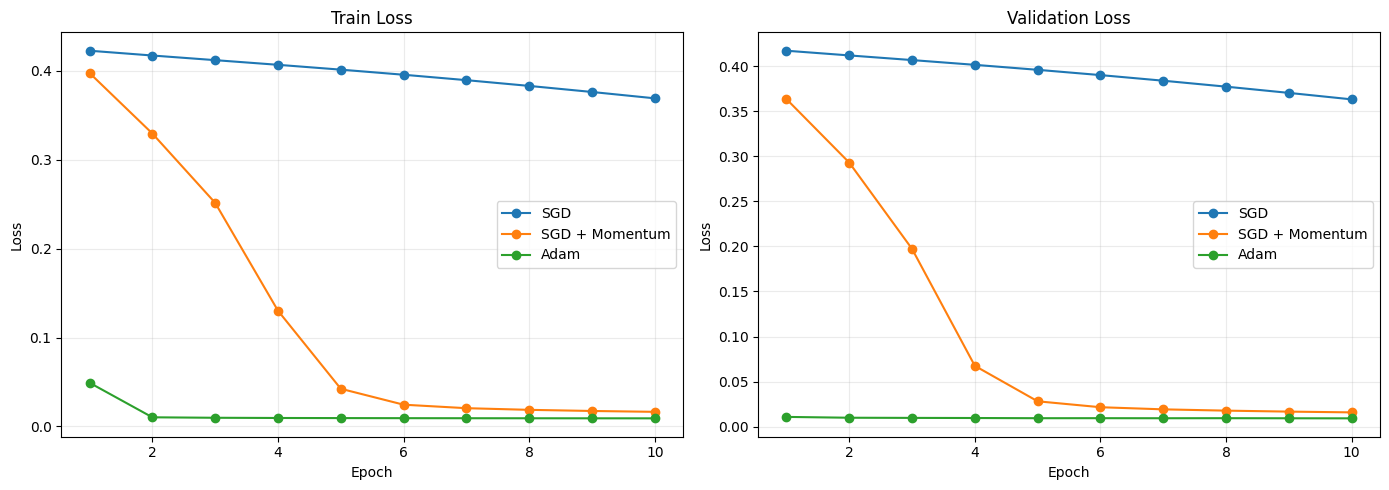

In [18]:
# Plot 1: Loss Curves
if "comparison_results" not in globals():
    raise ValueError("Run the optimizer experiment cell first to create 'comparison_results'.")

num_epochs = len(next(iter(comparison_results.values()))["train_loss"])
epochs_axis = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for optimizer_name, history in comparison_results.items():
    axes[0].plot(epochs_axis, history["train_loss"], marker="o", label=optimizer_name)
    axes[1].plot(epochs_axis, history["val_loss"], marker="o", label=optimizer_name)

axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


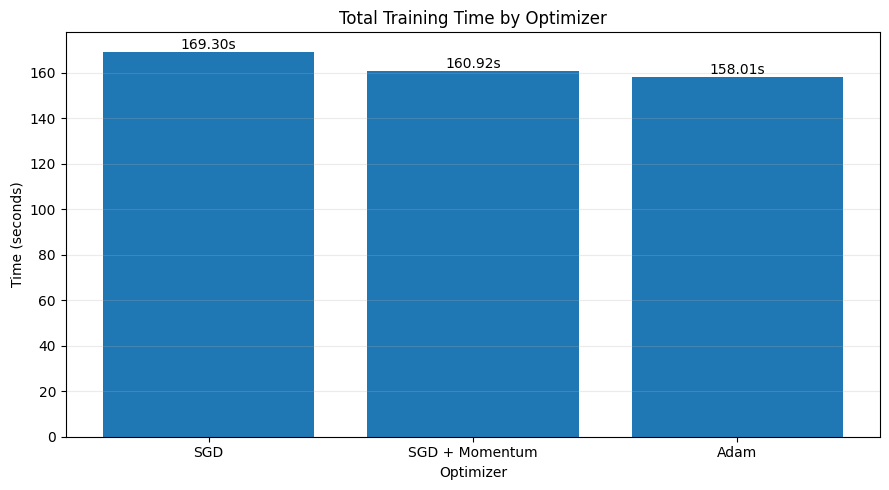

In [19]:
# Plot 2: Training Time Comparison
if "comparison_results" not in globals():
    raise ValueError("Run the optimizer experiment cell first to create 'comparison_results'.")

optimizer_names = list(comparison_results.keys())
total_times = [comparison_results[name]["total_time"] for name in optimizer_names]

plt.figure(figsize=(9, 5))
bars = plt.bar(optimizer_names, total_times)
plt.title("Total Training Time by Optimizer")
plt.xlabel("Optimizer")
plt.ylabel("Time (seconds)")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, total_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}s",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## **Optimizer Analysis**

---

# Results

My experiment:

| Optimizer      | Train Loss  | Val Loss    | Total Time |
| -------------- | ----------- | ----------- | ---------- |
| SGD            | 0.369       | 0.363       | 169s       |
| SGD + Momentum | 0.016       | 0.0158      | 160s       |
| Adam           | **0.00916** | **0.00922** | **158s**   |

---

> **Adam performed best overall**.

Because:

### Accuracy (Lower Loss = Better)

Adam:

```id="3g0edp"
Train loss: 0.00916
Val loss:   0.00922
```

SGD + Momentum:

```id="0ewozq"
Train loss: 0.0164
Val loss:   0.0158
```

Adam is **almost 2x better**.

So:

✅ Adam better accuracy
✅ Adam better generalization
✅ Adam faster training

Adam **wins here**.

---

# **Engineering-level summary**:

## Optimization Comparison Summary

I trained the same neural network using **SGD**, **SGD + Momentum**, and **Adam** to compare convergence speed, stability, and final performance.

### Observations

* **SGD performed worst**, with high train and validation loss (~0.36), showing slow convergence and unstable training.
* **SGD + Momentum significantly improved performance**, reducing loss to ~0.016, demonstrating that momentum helps smooth gradients and accelerate convergence.
* **Adam achieved the best performance**, with the lowest training and validation loss (~0.009) and slightly faster training time.

### Interpretation

* Momentum improved SGD by accumulating past gradients and reducing noisy updates.
* Adam further improved performance by combining momentum with adaptive learning rates.
* The job salary dataset appears to benefit from **adaptive learning rates**

### Decision

For this job salary prediction task:

**I would deploy Adam** because:

* Lowest validation loss
* Fastest convergence
* Most stable training

---
